In [ ]:
import importlib
import utils
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity

_ = importlib.reload(utils)


In [ ]:
# df = utils.get_revisions_data()
# df.to_csv("revisions_with_text.csv")


STEP 2: EXTRACTING INTRO TEXT
Loaded revisions: 11030 | Total revisions: 11030
Length of clean_intros: 11030
Current progress: 100.00%
Time elapsed (total): 788.256 s
Time elapsed (from last batch): 0.482 s
▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮


In [ ]:
df = pd.read_csv("revisions_with_text.csv")

In [29]:
wtext = df[df["intro_text"] != ""]
wtext["timestamp"] = pd.to_datetime(wtext["timestamp"])

In [30]:
wtext = wtext.sort_values(by="timestamp", ascending=True)

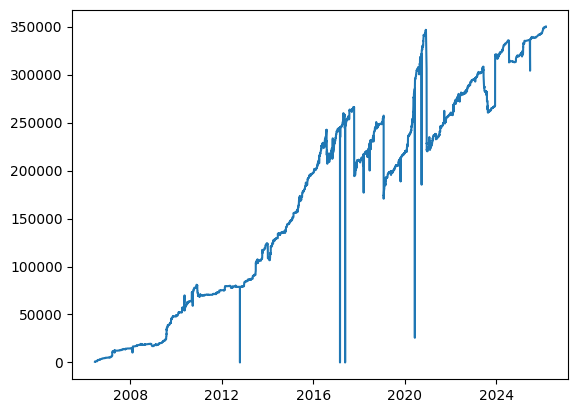

In [31]:
plt.plot(wtext["timestamp"], wtext["size"])

In [45]:
wtext["nwords_intro"] = wtext["intro_text"].apply(lambda x: len(x.split(" ")))

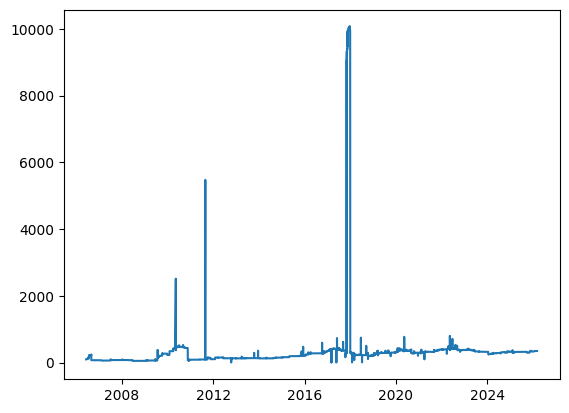

In [47]:
plt.plot(wtext["timestamp"], wtext["nwords_intro"])

In [61]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
corpus = wtext["intro_text"]
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(corpus)

feature_names = vectorizer.get_feature_names_out()
bow_matrix = X.toarray()

bow_df = pd.DataFrame(bow_matrix, columns=feature_names, index=corpus)
print("Vocabulary (Unique Words):")
print(feature_names)
# print("\nBag of Words Matrix (Word Frequencies):")
# print(df)

bow_df.to_csv("bow_df.csv")


Vocabulary (Unique Words):
['00' '000' '000th' ... 'zones' 'zurich' 'špek']


In [66]:
cos_sim = cosine_similarity(X[1:], X[:-1]).diagonal()
cos_sim = np.insert(cos_sim, 0, np.nan)


In [71]:
wtext["cosine"]=cos_sim
wtext.head()

,revid,parentid,timestamp,user,temp,comment,size,sha1,flags,intro_text,minor,nwords_intro,cosine
11029,58236565,0,2006-06-12 17:34:14+00:00,Ryddragyn,False,None,750,109090288474dc75eb4c9c7e6e5cac8a0f396f34,None,The Tesla Motor Company is a Silicon Valley st...,False,93,NaN
11028,58237833,58236565,2006-06-12 17:42:49+00:00,Ryddragyn,False,None,1007,010dc9f049ff89a0584341b7a0cb9b47784f94eb,None,The Tesla Motor Company is a Silicon Valley st...,True,93,1.0
11027,58964074,58237833,2006-06-16 16:31:34+00:00,Ryddragyn,False,None,1061,18d40df0c6ea0fa7cf34823d30e01106c1f2e3c4,None,The Tesla Motor Company is a Silicon Valley st...,False,93,1.0
11026,59642992,58964074,2006-06-20 15:58:51+00:00,Ryddragyn,False,None,1190,7614d754fdf90a4dc4048608908805ff55c94155,None,The Tesla Motor Company is a Silicon Valley st...,False,93,1.0
11025,59643087,59642992,2006-06-20 15:59:29+00:00,Ryddragyn,False,None,1195,3731acd13f8aebbb6296c63cff3c7d21109382f5,None,The Tesla Motor Company is a Silicon Valley st...,False,93,1.0


In [74]:
wtext["year"] = wtext["timestamp"].dt.year

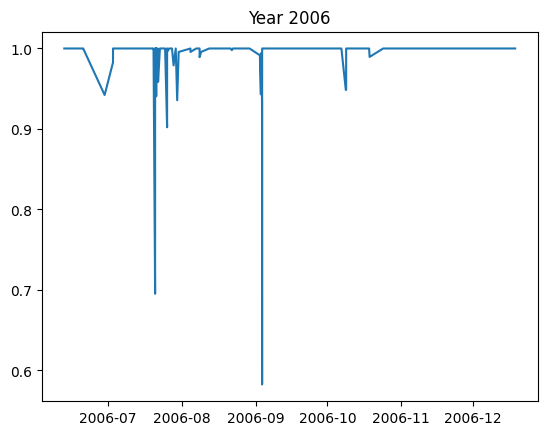

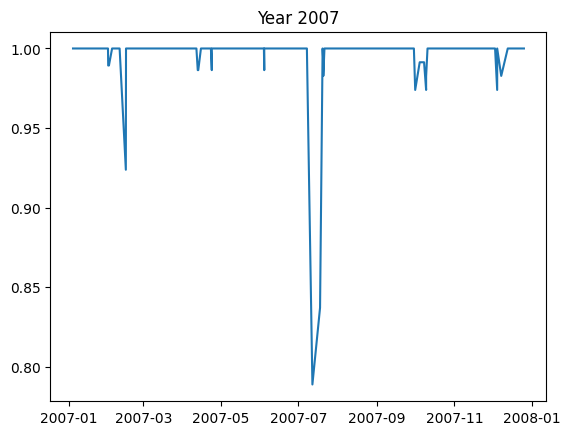

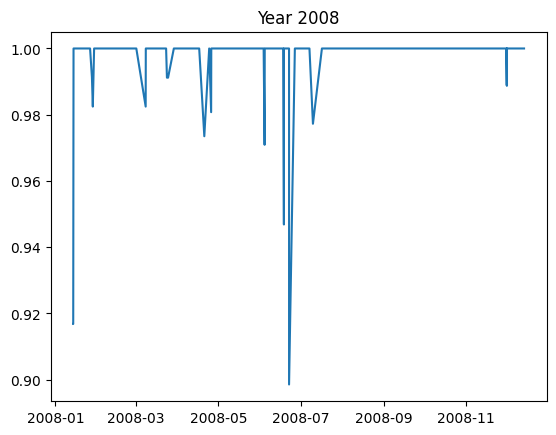

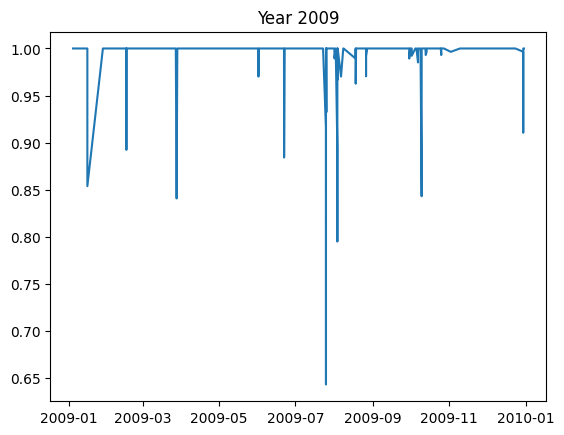

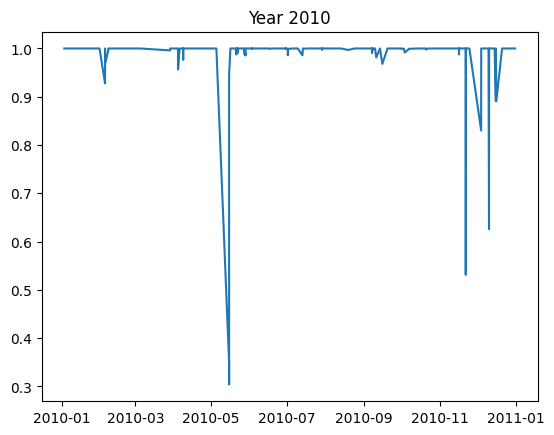

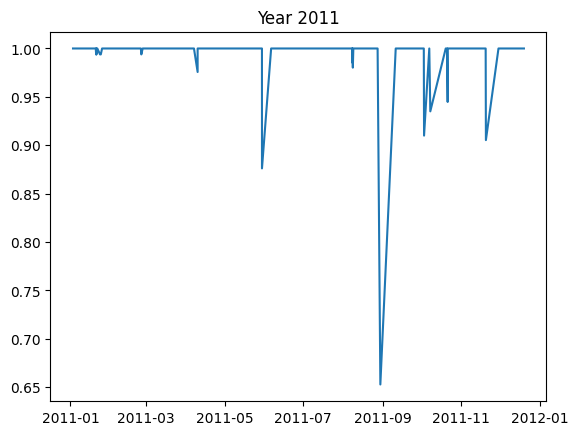

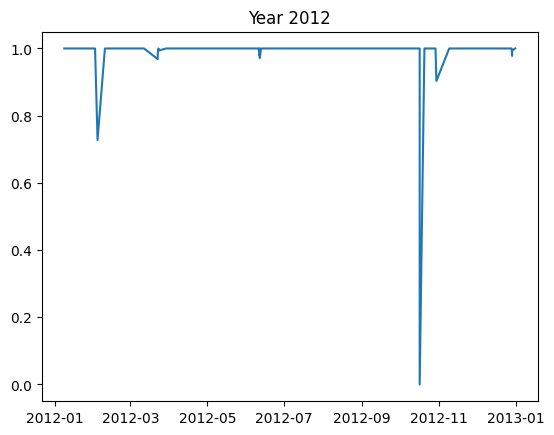

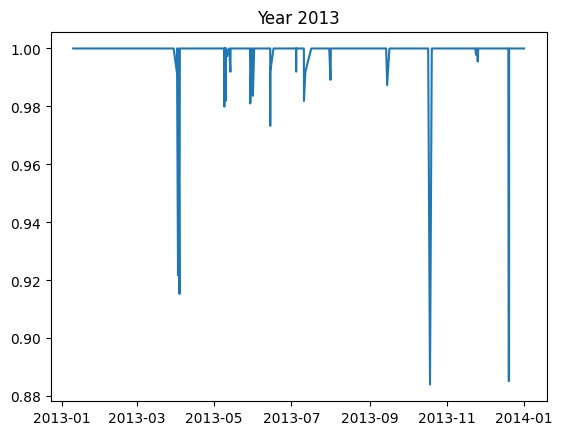

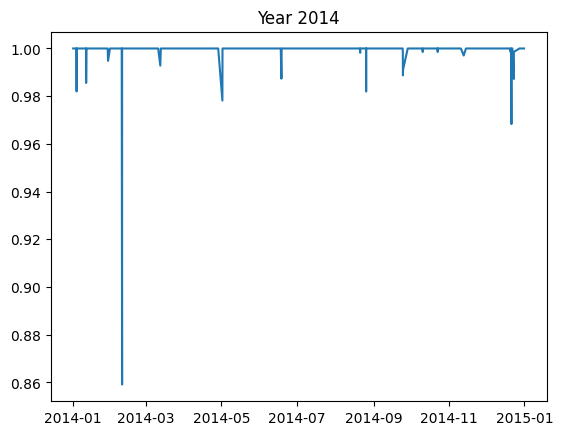

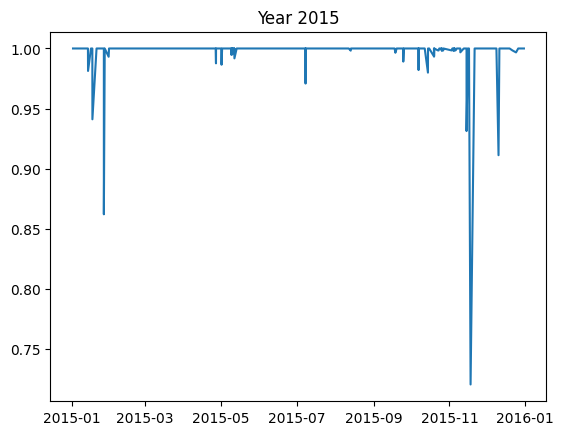

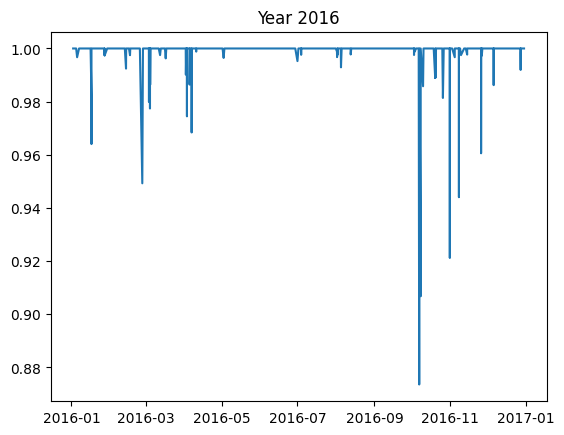

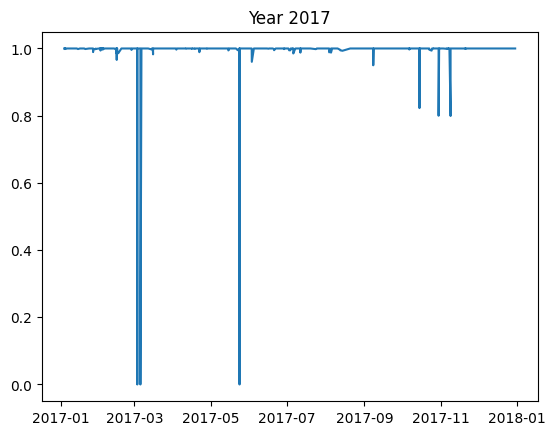

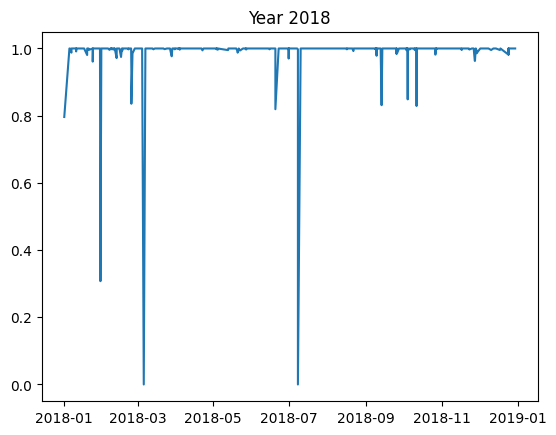

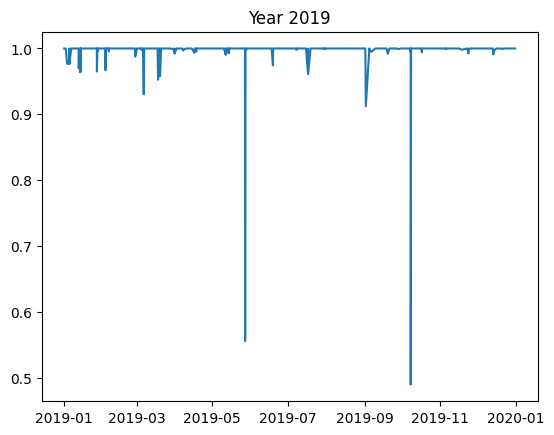

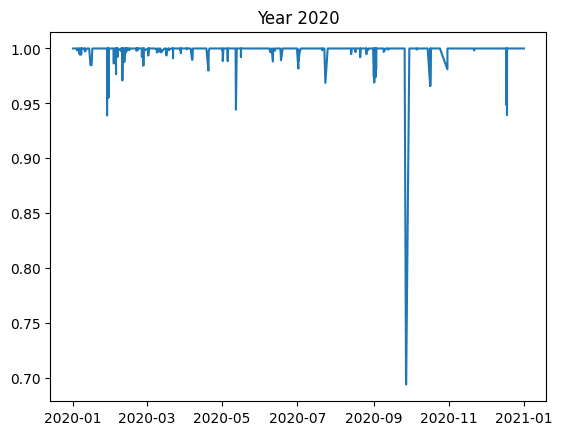

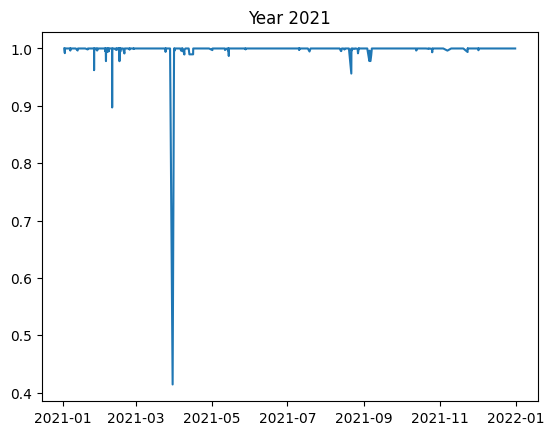

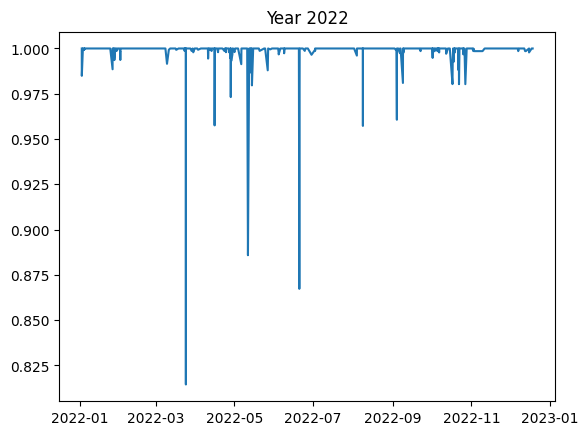

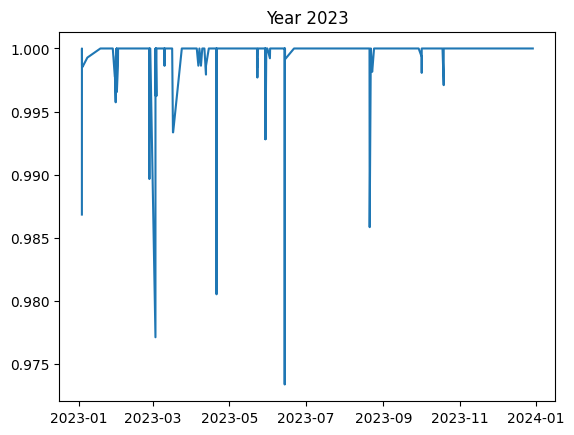

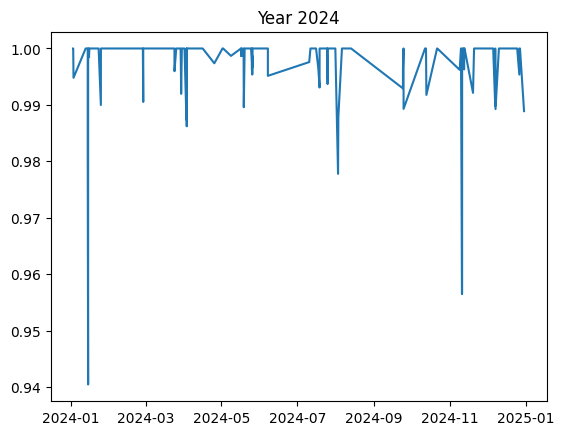

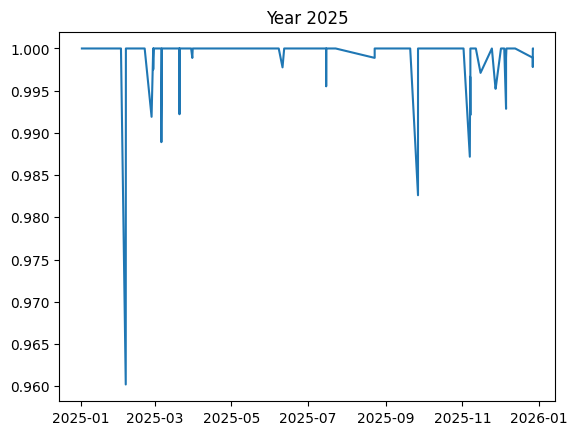

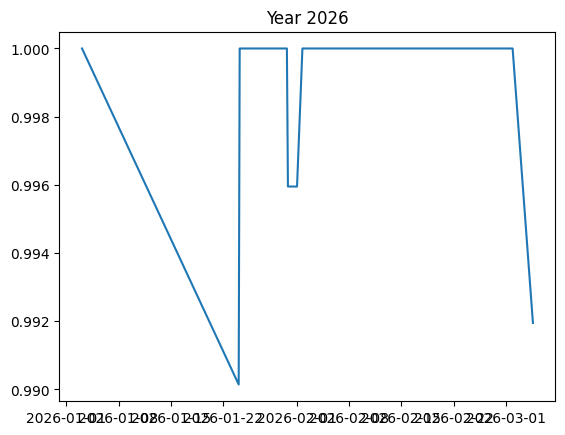

In [76]:
for year, group in wtext.groupby("year"):
    plt.figure()
    plt.plot(group["timestamp"], group["cosine"])
    plt.title(f"Year {year}")
    plt.show()

In [ ]:

cosine_baseline = cosine_similarity(X, X[0]).flatten()


array([1.        , 1.        , 1.        , ..., 0.3911715 , 0.3911715 ,
       0.38802319], shape=(10548,))

In [85]:
wtext["cosine_baseline"] = cosine_baseline

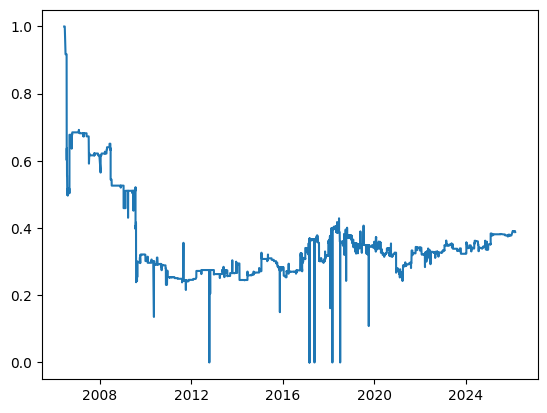

In [86]:
plt.plot(wtext["timestamp"], wtext["cosine_baseline"])

In [103]:
wtext_cleaned = wtext[wtext["cosine_baseline"] > 0.2]

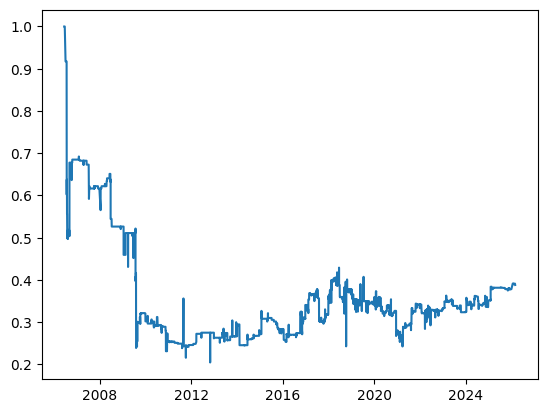

In [104]:
plt.plot(wtext_cleaned["timestamp"], wtext_cleaned["cosine_baseline"])